# From Sequence to Variant: Protein Language Models on CFDE Data

**A CFDE Training Center Community-Sourced Module**

**Author:** Saba Nafees, Ph.D.
**Estimated completion time:** ~2.5 hours
**Level:** Intermediate (working Python familiarity; basic biology background; no prior deep learning experience required)
**Environment:** Google Colab (no institutional compute cluster needed)

---

### What you will do in this notebook

You will connect two CFDE Data Coordinating Center resources — **MoTrPAC** (exercise multi-omics) and **GTEx** (expression quantitative trait loci, or eQTLs) — through a protein language model, **ESM2**, to ask a genuinely open scientific question:

> *Is exercise-responsiveness encoded in protein sequence — and do the sequence signatures a language model learns correspond to positions where natural genetic variation exists?*

**The three-layer story:**
1. **MoTrPAC** → which proteins change expression across tissues in response to exercise
2. **GTEx** → for those same genes, which regulatory variants (eQTLs) modulate their tissue-specific expression
3. **ESM2** → embed protein sequences, fine-tune to predict exercise-responsiveness, then check whether the sequence positions driving predictions overlap with known eQTL variant positions

By the end, you will have built a full, reproducible sequence-to-variant workflow that generalizes to *any* CFDE perturbation dataset — MoTrPAC is just today's example.

**A note on runtime:** cells that call MoTrPAC/GTEx APIs or download ESM2 need internet access and should be run inside Google Colab (or any environment with outbound access to `storage.googleapis.com`, `gtexportal.org`, and `huggingface.co`). Expected ESM2 embedding time for ~50–100 proteins on a standard Colab CPU runtime is roughly 5 minutes.


## How to use this notebook

- Sections marked **📍 Checkpoint** ask you to answer a short question about your own output before moving on — write your answer in the provided markdown cell.
- Sections marked **🧠 Concept Check** are ungraded self-checks, not the formal knowledge check.
- The formal **Pre-Module Knowledge Check** is immediately below, and the **Post-Module Knowledge Check** is at the very end — compare your answers before and after.
- All code cells are designed to run top-to-bottom in order.


---
## Pre-Module Knowledge Check (5 questions)

Answer these before starting — don't worry about getting them right. You'll revisit them at the end.

1. What does "eQTL" stand for, and in one sentence, what does an eQTL tell you biologically?
2. What is a protein language model, in your own words? Name one thing you think it might "learn" from millions of protein sequences.
3. MoTrPAC studies molecular responses to what kind of physiological perturbation?
4. True/False: fine-tuning a pre-trained model means training a new model from scratch on your own labels.
5. Why might it be scientifically interesting to compare which parts of a protein sequence a model "pays attention to" against known genetic variant positions?

*(Write your answers in the cell below — no need to be polished, this is a baseline.)*


**Your answers:**

1. 
2. 
3. 
4. 
5. 

---
## Part 0: Orientation (10 min)

### What is CFDE, and why does cross-program data integration matter?

The **Common Fund Data Ecosystem (CFDE)** connects data generated across NIH Common Fund programs — each run by an independent Data Coordinating Center (DCC), each with its own data types, formats, and access tools. Individually, these are powerful single-purpose resources. The scientific opportunity — and the harder technical problem — is *linking* them: asking a question that only makes sense when you combine information that lives in two different programs.

That is exactly what this module does: MoTrPAC tells you *which proteins respond to exercise*; GTEx tells you *what regulatory DNA variants control those same genes' expression*. Neither dataset alone answers the sequence-to-variant question we're asking today.

### MoTrPAC in brief

The **Molecular Transducers of Physical Activity Consortium (MoTrPAC)** measures multi-omic (transcriptomic, proteomic, and more) changes across many tissues in response to structured endurance exercise training. The dataset we'll use is the **rat 6-month endurance training study** — fully open, no registration required, licensed CC BY 4.0. "Exercise-responsive" in this context means a gene or protein shows a statistically significant expression change between exercise-trained and sedentary control animals in a given tissue.

### GTEx in brief

The **Genotype-Tissue Expression (GTEx)** project characterizes how genetic variation affects gene expression across dozens of human tissues. An **expression quantitative trait locus (eQTL)** is a genomic position where a DNA variant is statistically associated with the expression level of a nearby (or distant) gene. eQTLs are one of the primary tools researchers use to interpret what non-coding genetic variants might *do*.

### Why a protein language model bridges them

MoTrPAC gives us *labels* (exercise-responsive or not). GTEx gives us *variant positions*. What's missing is a way to ask whether something about the **protein sequence itself** predicts exercise-responsiveness — and if so, whether the sequence positions that matter to the model line up with the regulatory variant positions GTEx has already found. ESM2, a protein language model pre-trained on millions of sequences, gives us both a predictive model and an interpretability lens (attention weights, feature importance) to ask exactly that.


### 🧠 Concept Check (ungraded)
1. In your own words, why isn't MoTrPAC data alone enough to ask about genetic variants?
2. Why isn't GTEx data alone enough to ask about exercise-responsiveness?


In [ ]:
# ============================================================
# CELL PURPOSE: set up the Python environment. Run this cell first, every time.
# ============================================================

import sys
# This checks whether we're running inside Google Colab (vs. a local computer).
# "google.colab" is a module that only exists inside Colab notebooks.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # "!pip install" runs a command-line install of the Python packages this notebook needs.
    # -q means "quiet" (less scrolling text). You only need to do this once per Colab session.
    # pyreadr    -> lets Python read R's .rda data files (MoTrPAC's data format) without needing R
    # requests   -> lets Python make web requests (download files, call APIs)
    # biopython  -> biology-specific tools; we use its sequence-alignment feature in Part 4
    # fair-esm   -> Meta AI's protein language model (ESM2) that we fine-tune in Part 3
    # torch      -> PyTorch, the deep learning library ESM2 is built on
    # scikit-learn -> standard machine learning library (our classifier lives here)
    # matplotlib -> for making plots
    # pandas / numpy -> standard data-handling libraries (tables and math)
    !pip install -q pyreadr requests biopython fair-esm torch scikit-learn matplotlib pandas numpy

# "import" loads a library so we can use it later in the notebook.
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment ready. IN_COLAB =", IN_COLAB)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.3 MB/s eta 0:00:00
Environment ready. IN_COLAB = True


---
## Part 1: How Protein Language Models Encode Sequence (25 min)

### Intuition: what does ESM2 learn from millions of protein sequences?

ESM2 (Evolutionary Scale Modeling, v2) is trained the way large language models for text are trained — but on protein sequences instead of sentences. During training, random amino acids in a sequence are masked, and the model learns to predict the missing residue from context. Doing this over hundreds of millions of sequences forces the model to implicitly learn:

- Which amino acid substitutions are tolerated at a given position (and which aren't) — a proxy for structural and functional constraint
- Local structural motifs (e.g., patterns typical of alpha helices, beta sheets, active sites)
- Long-range dependencies between residues that are far apart in sequence but close in 3D structure

The result is that each amino acid position gets an **embedding** — a vector of numbers — that captures its functional and structural context, not just "which amino acid is this."

### Why embeddings carry functional signal

Because the model learned amino acid substitution tolerance implicitly, embeddings shift in predictable, meaningful ways when you introduce a mutation. A mutation at a highly constrained, functionally important position produces a larger embedding shift than a mutation at a tolerant, low-constraint position. This is the basis for **zero-shot variant effect prediction**: you can estimate how damaging a mutation might be just from how much it perturbs the model's internal representation — no labeled training data required.

### Zero-shot prediction vs. supervised fine-tuning

| | Zero-shot | Supervised fine-tuning (what we do today) |
|---|---|---|
| Requires labeled data? | No | Yes — we use MoTrPAC exercise-responsiveness as labels |
| What it answers | "Is this mutation likely disruptive?" | "Does this protein's sequence predict a specific phenotype (exercise-responsiveness)?" |
| When to use | Quick triage, no labels available | You have a specific outcome you want to predict, and some labeled examples |

Today we use **supervised fine-tuning**: MoTrPAC gives us the labels (responsive / not responsive), and we train a small classifier on top of frozen ESM2 embeddings to predict that label from sequence alone.


### 🧠 Concept Check (ungraded)
1. What is being masked and predicted during ESM2's pre-training, and how is that similar to how text language models are trained?
2. In this module, are we doing zero-shot prediction or supervised fine-tuning? Why does that choice make sense given what MoTrPAC provides?


---
## Part 2: Retrieving and Integrating CFDE Data (30 min)

### 2.1 MoTrPAC: load the rat 6-month endurance training dataset

MoTrPAC rat training data is available as direct Google Cloud Storage downloads — no R installation needed. We'll pull pre-computed differential analysis results (already-tested statistics comparing trained vs. sedentary animals) for one tissue as a working example, then generalize.

Data license: **CC BY 4.0**. Source: `storage.googleapis.com/motrpac-rat-training-6mo-extdata/`


**A note on where this data actually lives:** `TRNSCRPT_LIVER_DA` and similar per-tissue differential analysis (DA) objects are *not* standalone downloadable files on Google Cloud Storage — that GCS bucket (`motrpac-rat-training-6mo-extdata`) hosts only epigenomics (ATAC/METHYL) raw data and feature annotation files. The transcriptomics/proteomics DA objects are bundled as lazy-loaded R data objects inside the `MotrpacRatTraining6moData` package's `data/` folder on GitHub. We fetch the package source tarball once and extract just the two `.rda` files we need — this mirrors the package maintainers' own documented fallback for users who can't run `devtools::install_github()`.


In [7]:
# ============================================================
# CELL PURPOSE: download MoTrPAC's data package and pull out the one table we need
# (gene activity changes in liver tissue after 8 weeks of exercise training in rats).
# ============================================================
#
# BACKGROUND: MoTrPAC's detailed results (like "TRNSCRPT_LIVER_DA", which stands for
# "transcriptomics, liver tissue, differential analysis") are NOT sitting as individual
# downloadable files online. They're bundled inside the source code of an R software
# package on GitHub. Since this notebook uses Python (not R), we download that package's
# full source code as a single compressed file ("tarball"), then pull out just the one
# table we need from inside it — like unzipping a folder to grab a single spreadsheet.

import pyreadr   # lets Python read R's .rda file format
import os
import tarfile   # lets Python open .tar.gz compressed archives
import io

TISSUE = "LIVER"
ASSAY = "TRNSCRPT"   # "TRNSCRPT" = transcriptomics (gene activity / RNA levels)

# This is the exact web address of the MoTrPAC package's source code on GitHub.
TARBALL_URL = "https://api.github.com/repos/MoTrPAC/MotrpacRatTraining6moData/tarball/HEAD"
TARBALL_PATH = "/tmp/motrpac_data_pkg.tar.gz"  # where we'll save the download on this computer

# Only download if we haven't already (the file is a few hundred MB, so this saves time
# if you re-run this cell later in the same session).
if not os.path.exists(TARBALL_PATH):
    print("Downloading MotrpacRatTraining6moData package source (one-time, ~several hundred MB)...")
    with requests.get(TARBALL_URL, stream=True, timeout=300) as r:
        r.raise_for_status()  # this stops the notebook with a clear error if the download failed
        with open(TARBALL_PATH, "wb") as f:
            # Download in chunks (1 MB at a time) rather than all at once — more memory-friendly.
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    print("Download complete.")
else:
    print("Package tarball already downloaded, reusing cached copy.")

def extract_rda_object(tarball_path, object_name):
    """Pull one specific .rda file out of the downloaded package archive, by name.
    Example: extract_rda_object(TARBALL_PATH, "TRNSCRPT_LIVER_DA") finds and saves just
    that one table, without needing to unpack the entire multi-hundred-MB archive to disk."""
    target_suffix = f"data/{object_name}.rda"
    with tarfile.open(tarball_path, "r:gz") as tar:
        # Look through every file in the archive until we find the one whose path ends with
        # what we're looking for (e.g. ".../data/TRNSCRPT_LIVER_DA.rda").
        member = next((m for m in tar.getmembers() if m.name.endswith(target_suffix)), None)
        if member is None:
            raise FileNotFoundError(f"Could not find {target_suffix} in package tarball")
        extracted = tar.extractfile(member)
        out_path = f"/tmp/{object_name}.rda"
        with open(out_path, "wb") as f:
            f.write(extracted.read())
        return out_path

# Build the exact object name we want, e.g. "TRNSCRPT_LIVER_DA", and extract + load it.
da_object_name = f"{ASSAY}_{TISSUE}_DA"
da_local_path = extract_rda_object(TARBALL_PATH, da_object_name)

# pyreadr.read_r() converts the R data file into a Python dictionary of pandas DataFrames
# (a DataFrame is just a spreadsheet-like table). We grab the first (and only) table inside.
result = pyreadr.read_r(da_local_path)
da_df = result[list(result.keys())[0]]
print(f"Loaded {da_object_name}: {da_df.shape[0]} rows, {da_df.shape[1]} columns")
da_df.head()  # .head() shows just the first few rows, as a quick preview

Package tarball already downloaded, reusing cached copy.
Loaded TRNSCRPT_LIVER_DA: 115496 rows, 22 columns


,feature,assay,assay_code,tissue,tissue_code,feature_ID,sex,comparison_group,p_value,adj_p_value,...,shrunk_logFC,shrunk_logFC_se,zscore,covariates,removed_samples,comparison_average_intensity,comparison_average_intensity_se,reference_average_intensity,reference_average_intensity_se,selection_fdr
0,NaN,TRNSCRPT,transcript-rna-seq,LIVER,t68-liver,ENSRNOG00000000021,male,1w,0.334319,1.0,...,0.000317,0.009321,0.965450,"pct_globin,rin,pct_umi_dup,median_5_3_bias",4.457362e-313,141.755683,7.197998,133.053666,10.862639,1.0
1,NaN,TRNSCRPT,transcript-rna-seq,LIVER,t68-liver,ENSRNOG00000000021,male,2w,0.186084,1.0,...,0.002813,0.026289,1.322254,"pct_globin,rin,pct_umi_dup,median_5_3_bias",4.457362e-313,151.997323,12.051268,133.053666,10.862639,1.0
2,NaN,TRNSCRPT,transcript-rna-seq,LIVER,t68-liver,ENSRNOG00000000021,male,4w,0.855643,1.0,...,-0.001280,0.037714,-0.181923,"pct_globin,rin,pct_umi_dup,median_5_3_bias",4.457362e-313,128.585613,12.419618,133.053666,10.862639,1.0
3,NaN,TRNSCRPT,transcript-rna-seq,LIVER,t68-liver,ENSRNOG00000000021,male,8w,0.259868,1.0,...,0.026606,0.072070,1.126704,"pct_globin,rin,pct_umi_dup,median_5_3_bias",4.457362e-313,149.571226,11.861613,133.053666,10.862639,1.0
4,NaN,TRNSCRPT,transcript-rna-seq,LIVER,t68-liver,ENSRNOG00000000021,female,1w,0.063956,1.0,...,0.011495,0.031501,1.852489,"pct_globin,rin,pct_umi_dup,median_5_3_bias",4.457362e-313,167.207176,4.490465,145.590368,13.327682,1.0


### ⚠️ Important structural note about this table

`TRNSCRPT_LIVER_DA` is a **timewise** table: one row per gene *per training duration*
(`comparison_group` = `1w`, `2w`, `4w`, or `8w` of endurance training vs. sex-matched sedentary
controls), separately per sex. It is not one row per gene overall. Two consequences:

1. There is no `gene_symbol` column in this table — the gene identifier is the Ensembl ID in
   `feature_ID`. We map this to a readable gene symbol using MoTrPAC's `FEATURE_TO_GENE_FILT`
   table below (a bundled package object, pulled from the same tarball as the DA data).
2. To call a gene "exercise-responsive" we need to pick a specific comparison. We use the
   **8-week endurance-trained vs. sedentary** comparison (the longest, most-trained timepoint)
   as our working definition for this module.


In [9]:
# ============================================================
# CELL PURPOSE: get a lookup table that translates cryptic gene IDs (like
# "ENSRNOG00000000021") into readable gene names (like "Eno2").
# ============================================================
# FEATURE_TO_GENE_FILT is another table bundled inside the same MoTrPAC package we already
# downloaded above, so this reuses the tarball we already have on disk (fast, no new download).

f2g_path = extract_rda_object(TARBALL_PATH, "FEATURE_TO_GENE_FILT")
f2g_result = pyreadr.read_r(f2g_path)
feature_to_gene = f2g_result[list(f2g_result.keys())[0]]
print("FEATURE_TO_GENE_FILT columns:", feature_to_gene.columns.tolist())
# Preview just the 3 columns we actually care about: the cryptic ID, the readable gene name,
# and its Ensembl gene ID (a standardized identifier used across many biology databases).
feature_to_gene[["feature_ID", "gene_symbol", "ensembl_gene"]].head()

FEATURE_TO_GENE_FILT columns: ['entrez_gene', 'feature_ID', 'rgd_gene', 'gene_symbol', 'old_gene_symbol', 'ensembl_gene', 'relationship_to_gene', 'custom_annotation', 'kegg_id']


,feature_ID,gene_symbol,ensembl_gene
0,NP_036620.2,A2m,ENSRNOG00000028896
1,NP_036620.2,A2m,ENSRNOG00000045772
2,NP_036621.1,Acaa1a,ENSRNOG00000032908
3,NP_036621.1_S253s,Acaa1a,ENSRNOG00000032908
4,NP_036621.1_S261s,Acaa1a,ENSRNOG00000032908


In [13]:
# ============================================================
# CELL PURPOSE: decide which genes count as "exercise-responsive" and get their names.
# ============================================================
print(da_df.columns.tolist())  # print all column names so we can see exactly what data we have

TIMEPOINT = "8w"   # we're using the 8-week (longest) training duration as our comparison
PVAL_COL = "p_value"        # the statistical significance of the gene's change (lower = more confident)
LFC_COL = "logFC" if "logFC" in da_df.columns else "shrunk_logFC"  # size of the change (bigger = stronger effect)
FEATURE_ID_COL = "feature_ID"
GENE_COL = "gene_symbol"

# Keep only the rows for our chosen 8-week timepoint (the table has separate rows for
# 1-week, 2-week, 4-week, and 8-week comparisons — we only want one of them).
timepoint_df = da_df[da_df["comparison_group"] == TIMEPOINT].copy()

# A gene can sometimes appear more than once (e.g. from different measurement probes).
# Here we keep only the most statistically significant (lowest p-value) row per gene.
timepoint_df = timepoint_df.sort_values(PVAL_COL).drop_duplicates(subset=FEATURE_ID_COL, keep="first")

# Attach a readable gene name to each row, using the lookup table from the cell above.
# "merge" is like a spreadsheet VLOOKUP: it matches rows between two tables on a shared column.
timepoint_df = timepoint_df.merge(
    feature_to_gene[["feature_ID", GENE_COL]].drop_duplicates(subset="feature_ID"),
    on=FEATURE_ID_COL, how="left"
)
# Drop any rows where we couldn't find a matching gene name.
timepoint_df = timepoint_df.dropna(subset=[GENE_COL])

# We use the "nominal" (unadjusted) p-value here rather than the more conservative
# "adjusted" p-value. Why: when you test thousands of genes across four timepoints at once,
# standard statistical correction (which guards against false positives) becomes very strict
# and would leave us with almost no genes to work with for a teaching example. This is a
# simplification made for pedagogical purposes, flagged here explicitly.
SIG_THRESHOLD = 0.05
responsive = timepoint_df[timepoint_df[PVAL_COL] < SIG_THRESHOLD].copy()
# Sort so the genes with the BIGGEST change (regardless of direction, hence abs = absolute value)
# come first.
responsive = responsive.sort_values(LFC_COL, key=abs, ascending=False)

print(f"{len(responsive)} exercise-responsive genes at nominal p < {SIG_THRESHOLD} ({TIMEPOINT} vs. sedentary, {TISSUE})")
# Take just the top 75 genes by effect size to keep the rest of the notebook fast to run.
top_genes = responsive[GENE_COL].head(75).tolist()
print("Top genes by |log fold-change|:", top_genes[:15], "...")

['feature', 'assay', 'assay_code', 'tissue', 'tissue_code', 'feature_ID', 'sex', 'comparison_group', 'p_value', 'adj_p_value', 'logFC', 'logFC_se', 'shrunk_logFC', 'shrunk_logFC_se', 'zscore', 'covariates', 'removed_samples', 'comparison_average_intensity', 'comparison_average_intensity_se', 'reference_average_intensity', 'reference_average_intensity_se', 'selection_fdr']
2614 exercise-responsive genes at nominal p < 0.05 (8w vs. sedentary, LIVER)
Top genes by |log fold-change|: ['Eno2', 'AC141220.4', 'Pak2', 'AABR07032202.1', 'Lig1', 'Gns', 'LOC108348081', 'Cbr1', 'Mast4', 'AABR07046657.1', 'Ppfia1', 'Hdac6', 'Ltb', 'AABR07067882.1', 'Aldh18a1'] ...


### 2.2 GTEx: query the V2 API for eQTLs on the same genes

Now we ask: for these same MoTrPAC exercise-responsive genes, does GTEx report regulatory variants (eQTLs) that modulate their expression?

**Important species issue:** MoTrPAC is a *rat* study, but GTEx is *human-only* data. The gene
symbols we have so far (e.g. `Eno2`, `Pak2`) are rat gene symbols with rat-style casing — querying
GTEx directly with these will fail (GTEx expects human gene symbols, which use different casing
conventions, e.g. `ENO2`, `PAK2`, and won't reliably string-match rat casing even where the
ortholog exists). We first convert each rat gene to its human ortholog using MoTrPAC's own
`RAT_TO_HUMAN_GENE` mapping (bundled in the same package tarball), then query GTEx using the
correct human symbol.

GTEx API v2 base: `https://gtexportal.org/api/v2` — no login required.


In [14]:
# ============================================================
# CELL PURPOSE: translate rat gene names into their human equivalents.
# ============================================================
# WHY THIS STEP EXISTS: MoTrPAC studied RATS, but GTEx (the next dataset we'll query) only
# has HUMAN data. Many genes have a "matching" gene in another species (called an ortholog) —
# e.g. rat "Eno2" and human "ENO2" do the same job. Before we can look up anything in GTEx,
# we need to know each rat gene's human counterpart.

# RAT_TO_HUMAN_GENE is (again) a table bundled inside the MoTrPAC package we already downloaded.
r2h_path = extract_rda_object(TARBALL_PATH, "RAT_TO_HUMAN_GENE")
r2h_result = pyreadr.read_r(r2h_path)
rat_to_human = r2h_result[list(r2h_result.keys())[0]]
print("RAT_TO_HUMAN_GENE columns:", rat_to_human.columns.tolist())

# Build a simple lookup dictionary: {rat gene name: human gene name}.
# Some rat genes don't have a single clear human match — we drop those (dropna) and keep
# only the first match if there's more than one candidate (drop_duplicates).
rat_to_human_map = (
    rat_to_human.dropna(subset=["RAT_SYMBOL", "HUMAN_ORTHOLOG_SYMBOL"])
    .drop_duplicates(subset="RAT_SYMBOL", keep="first")
    .set_index("RAT_SYMBOL")["HUMAN_ORTHOLOG_SYMBOL"]
    .to_dict()
)

# Filter our 75 top genes down to just the ones that DO have a known human match.
human_ortholog_genes = {g: rat_to_human_map[g] for g in top_genes if g in rat_to_human_map}
n_missing = len(top_genes) - len(human_ortholog_genes)
print(f"{len(human_ortholog_genes)} / {len(top_genes)} top genes have a known human ortholog "
      f"({n_missing} have no 1:1 rat-human ortholog and will be skipped for the GTEx step).")
list(human_ortholog_genes.items())[:10]  # preview the first 10 rat -> human gene name pairs

RAT_TO_HUMAN_GENE columns: ['RAT_SYMBOL', 'NAME', 'RAT_GENE_RGD_ID', 'RAT_NCBI_GENE_ID', 'RAT_ENSEMBL_ID', 'RAT_UNIPROT_ID', 'RAT_OLD_SYMBOL', 'HUMAN_ORTHOLOG_SYMBOL', 'HUMAN_ORTHOLOG_RGD', 'HUMAN_ORTHOLOG_NCBI_GENE_ID', 'HUMAN_ORTHOLOG_ENSEMBL_ID', 'HUMAN_ORTHOLOG_SOURCE']
49 / 75 top genes have a known human ortholog (26 have no 1:1 rat-human ortholog and will be skipped for the GTEx step).


[('Eno2', 'ENO2'),
 ('Pak2', 'PAK2'),
 ('Lig1', 'LIG1'),
 ('Gns', 'GNS'),
 ('Cbr1', 'CBR1'),
 ('Mast4', 'MAST4'),
 ('Ppfia1', 'PPFIA1'),
 ('Hdac6', 'HDAC6'),
 ('Ltb', 'LTB'),
 ('Aldh18a1', 'ALDH18A1')]

In [21]:
# ============================================================
# CELL PURPOSE: test our GTEx query on ONE well-known gene before running it on all 49,
# to make sure the query itself works correctly.
# ============================================================
# SORT1 is chosen because it has one of the most famous, well-documented liver eQTLs in the
# scientific literature (linked to LDL cholesterol levels) — if our query can't find SORT1's
# eQTLs, something is wrong with our query, not with the biology.
#
# TECHNICAL NOTE (learned through trial and error while building this notebook): GTEx's API
# does NOT accept a plain gene name like "SORT1" as a search term for this particular type of
# query. It requires a "GENCODE ID" — a precise, versioned genetic identifier that looks like
# "ENSG00000134243.11". So we first have to look up SORT1's GENCODE ID, THEN use that ID to
# search for its eQTLs. This is a two-step process: resolve name -> ID, then ID -> results.
GTEX_BASE = "https://gtexportal.org/api/v2"
GTEX_TISSUE = "Liver"  # must match GTEx's exact naming for tissues
GENCODE_VERSION = "v26"  # the specific gene-annotation version behind the GTEx dataset we're using

def resolve_gencode_id(gene_symbol, gencode_version=GENCODE_VERSION):
    """Look up a human gene's official versioned GENCODE ID from its plain name."""
    resp = requests.get(
        f"{GTEX_BASE}/reference/gene",
        params={"geneId": gene_symbol, "gencodeVersion": gencode_version},
        timeout=30,
    )
    resp.raise_for_status()
    genes = resp.json().get("data", [])
    if not genes:
        return None
    return genes[0].get("gencodeId")

sort1_gencode_id = resolve_gencode_id("SORT1")
print("Resolved SORT1 ->", sort1_gencode_id)

# Now use that GENCODE ID to actually search for SORT1's eQTLs in liver tissue.
diagnostic_params = {
    "gencodeId": [sort1_gencode_id],
    "tissueSiteDetailId": ["Liver"],
    "datasetId": "gtex_v8",
    "itemsPerPage": 50,
}
diag_resp = requests.get(f"{GTEX_BASE}/association/singleTissueEqtl", params=diagnostic_params, timeout=30)
print("Status code:", diag_resp.status_code)  # 200 = success; anything else means something's wrong
print("Response (first 1000 chars):", diag_resp.text[:1000])

Resolved SORT1 -> ENSG00000134243.11
Status code: 200
Response (first 1000 chars): {"data":[{"snpId":"rs34680256","pos":109052758,"snpIdUpper":"RS34680256","variantId":"chr1_109052758_G_C_b38","geneSymbol":"SORT1","pValue":1.04754e-05,"geneSymbolUpper":"SORT1","datasetId":"gtex_v8","tissueSiteDetailId":"Liver","ontologyId":"UBERON:0001114","chromosome":"chr1","gencodeId":"ENSG00000134243.11","nes":0.518678},{"snpId":"rs35389458","pos":109061071,"snpIdUpper":"RS35389458","variantId":"chr1_109061071_T_A_b38","geneSymbol":"SORT1","pValue":1.529e-06,"geneSymbolUpper":"SORT1","datasetId":"gtex_v8","tissueSiteDetailId":"Liver","ontologyId":"UBERON:0001114","chromosome":"chr1","gencodeId":"ENSG00000134243.11","nes":0.559451},{"snpId":"rs28663119","pos":109063742,"snpIdUpper":"RS28663119","variantId":"chr1_109063742_T_G_b38","geneSymbol":"SORT1","pValue":1.529e-06,"geneSymbolUpper":"SORT1","datasetId":"gtex_v8","tissueSiteDetailId":"Liver","ontologyId":"UBERON:0001114","chromosome":"chr1","gen

In [29]:
# ============================================================
# CELL PURPOSE: now that we know the query works (from the diagnostic cell above), run it
# for real across all of our exercise-responsive genes.
# ============================================================

def get_gtex_eqtls(human_gene_symbol, tissue_site_detail_id=GTEX_TISSUE, page_size=50):
    """For one human gene, find all its statistically significant regulatory variants
    (eQTLs) in the given tissue. Internally this does the same two-step lookup as the
    diagnostic cell above: gene name -> GENCODE ID -> eQTL results."""
    gencode_id = resolve_gencode_id(human_gene_symbol)
    if gencode_id is None:
        # Not every gene has a resolvable GENCODE ID in this exact annotation version —
        # if that happens, we skip it and move on rather than crashing the whole loop.
        print(f"  [warn] Could not resolve GENCODE ID for {human_gene_symbol} — skipping")
        return []
    endpoint = f"{GTEX_BASE}/association/singleTissueEqtl"
    params = {
        "gencodeId": [gencode_id],
        "tissueSiteDetailId": [tissue_site_detail_id],
        "datasetId": "gtex_v8",
        # itemsPerPage controls how many results we ask for. We set this high (500) because
        # some genes genuinely have hundreds of significant eQTLs — a low limit here would
        # silently cut off real results without any error message.
        "itemsPerPage": page_size,
    }
    try:
        resp = requests.get(endpoint, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json().get("data", [])
        return data
    except requests.exceptions.RequestException as e:
        print(f"  [warn] GTEx query failed for {human_gene_symbol}: {e}")
        return []

# Loop over every rat gene -> human ortholog pair, query GTEx, and collect every eQTL hit
# into one big list of dictionaries (which we'll turn into a table next).
eqtl_records = []
for rat_gene, human_gene in human_ortholog_genes.items():
    hits = get_gtex_eqtls(human_gene, page_size=500)  # 500 avoids silent truncation — some genes (e.g. ALDH18A1) have 400+ significant eQTLs
    for h in hits:
        eqtl_records.append({
            "rat_gene_symbol": rat_gene,       # keep track of the ORIGINAL rat gene name too
            "human_gene_symbol": human_gene,
            "variant_id": h.get("variantId"),   # unique ID for this specific genetic variant
            "chromosome": h.get("chromosome"),
            "pos": h.get("pos"),                # exact genomic position (in base pairs)
            "pValue": h.get("pValue"),          # statistical confidence of this eQTL
            "nes": h.get("nes"),                # normalized effect size — how strongly this variant affects gene expression
        })

# Convert our list of results into a proper table (DataFrame) for easy filtering/analysis later.
eqtl_df = pd.DataFrame(eqtl_records)
n_genes_with_hits = eqtl_df["rat_gene_symbol"].nunique() if len(eqtl_df) else 0
print(f"Retrieved eQTL records for {n_genes_with_hits} / {len(human_ortholog_genes)} queried genes "
      f"(query failures logged as [warn] above, if any — a gene simply having zero significant "
      f"eQTLs in this tissue is a normal, valid result, not a failure)")
eqtl_df.head()

  [warn] Could not resolve GENCODE ID for H4C9 — skipping
  [warn] Could not resolve GENCODE ID for EEF1AKMT3 — skipping
Retrieved eQTL records for 13 / 49 queried genes


,rat_gene_symbol,human_gene_symbol,variant_id,chromosome,pos,pValue,nes
0,Lig1,LIG1,chr19_47535245_A_G_b38,chr19,47535245,0.000006,-0.412796
1,Lig1,LIG1,chr19_47540986_A_G_b38,chr19,47540986,0.000006,-0.412796
2,Lig1,LIG1,chr19_47541024_T_C_b38,chr19,47541024,0.000006,-0.412796
3,Lig1,LIG1,chr19_48113401_C_A_b38,chr19,48113401,0.000009,-0.536519
4,Lig1,LIG1,chr19_48120183_G_A_b38,chr19,48120183,0.000009,-0.536519


In [32]:
# ============================================================
# CELL PURPOSE: combine everything so far into one master table: for each gene, do we know
# (a) how it responds to exercise (from MoTrPAC), and (b) whether it has any known regulatory
# genetic variants (from GTEx)?
# ============================================================

genes_with_eqtls = set(eqtl_df["rat_gene_symbol"].unique()) if len(eqtl_df) else set()

# Start from our original 75 exercise-responsive genes.
integrated = responsive[responsive[GENE_COL].isin(top_genes)].copy()

# De-duplicate by gene symbol: multiple Ensembl feature_IDs can map to the same gene_symbol
# (paralog annotations, readthrough transcripts, etc. in FEATURE_TO_GENE_FILT), which would
# otherwise leave duplicate rows and break the 1:1 gene <-> embedding <-> label alignment we
# rely on in Part 3. Keep the most significant (lowest p-value) row per gene symbol.
integrated = integrated.sort_values(PVAL_COL).drop_duplicates(subset=GENE_COL, keep="first")

# Add three new "yes/no or count" columns to our table, one gene at a time:
integrated["has_human_ortholog"] = integrated[GENE_COL].isin(human_ortholog_genes.keys())
integrated["has_eqtl"] = integrated[GENE_COL].isin(genes_with_eqtls)
integrated["n_eqtls"] = integrated[GENE_COL].map(
    eqtl_df.groupby("rat_gene_symbol").size() if len(eqtl_df) else {}
).fillna(0).astype(int)

# Print a readable preview of the combined table.
print(integrated[[GENE_COL, LFC_COL, PVAL_COL, "has_human_ortholog", "has_eqtl", "n_eqtls"]].head(20))

       gene_symbol     logFC       p_value  has_human_ortholog  has_eqtl  \
0       AC141220.4  51.53481  3.119341e-27               False     False   
1             Eno2  52.12958  2.862024e-24                True     False   
2              Gns  44.70768  7.508159e-21                True     False   
3             Pak2  48.69121  7.938778e-21                True     False   
4             Lig1  47.73748  1.735438e-20                True      True   
5   AABR07032202.1 -47.93350  3.657893e-20               False     False   
6     LOC108348081  43.79024  1.672284e-17               False     False   
7             Cbr1 -39.93247  2.031989e-14                True      True   
9            Mast4 -38.16385  1.665467e-13                True     False   
11  AABR07035479.1  21.08730  8.261140e-13               False     False   
12           Hdac6  30.16172  9.112471e-13                True     False   
15           Casp6  24.35821  2.973066e-11                True     False   
16  AABR0704

### 📍 Data Checkpoint

Before moving on, describe your integrated dataset in the cell below:
- How many exercise-responsive proteins/genes did you identify in your chosen tissue?
- Of those, how many have at least one GTEx eQTL hit?
- What does it mean, biologically, if a gene is exercise-responsive but has *no* eQTL coverage in GTEx — is that a strong negative, or just a data-coverage limitation? Explain.


**Your answer:**



---
## Part 3: Fine-Tuning ESM2 for Exercise-Responsiveness (45 min)

We now extract ESM2 embeddings for the protein sequences of our labeled gene set, then train a classifier on top of those embeddings to predict exercise-responsiveness.

We use the smallest ESM2 checkpoint (`esm2_t6_8M_UR50D`) so this runs comfortably on a standard Colab CPU runtime — larger checkpoints (150M+) will give better accuracy if you have GPU access and want to extend this after class.


In [33]:
# ============================================================
# CELL PURPOSE: get the actual amino acid sequence (the "letters" that make up each protein)
# for every gene in our list, since ESM2 needs the raw sequence, not just the gene's name.
# ============================================================
# UniProt is the standard public database of protein sequences. We ask it, for each gene name,
# "give me the officially reviewed rat protein sequence for this gene."

def get_uniprot_sequence(gene_symbol, organism_id="10116"):  # 10116 = the species code for Rattus norvegicus (rat)
    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": f"gene:{gene_symbol} AND organism_id:{organism_id} AND reviewed:true",
        "format": "fasta",  # FASTA is the standard plain-text format for biological sequences
        "size": 1,          # we only want the single best/canonical match
    }
    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        fasta = resp.text
        if not fasta.strip():
            return None  # no sequence found for this gene
        # A FASTA file's first line is a description (starts with ">"); every line after that
        # is the actual sequence, which we join together into one continuous string.
        lines = fasta.strip().split("\n")
        seq = "".join(lines[1:])
        return seq
    except requests.exceptions.RequestException:
        return None

sequences = {}
for gene in integrated[GENE_COL].tolist():
    seq = get_uniprot_sequence(gene)
    if seq:
        sequences[gene] = seq
    # If seq is None, we simply skip that gene — not every gene has a "reviewed" (high
    # confidence, manually checked) entry in UniProt, especially for less-studied genes.

print(f"Retrieved sequences for {len(sequences)} / {len(integrated)} genes")
# Keep only the genes we actually got a sequence for, going forward.
integrated = integrated[integrated[GENE_COL].isin(sequences.keys())].reset_index(drop=True)

Retrieved sequences for 27 / 74 genes


In [34]:
# ============================================================
# CELL PURPOSE: run each protein sequence through ESM2 (a pre-trained AI model) to turn it
# into a list of numbers ("embedding") that captures its functional and structural properties.
# ============================================================
# Think of an embedding as a fingerprint: proteins with similar structure/function end up
# with similar embeddings, even though the model was never explicitly told what "similar"
# means — it learned this by studying millions of protein sequences during its own training.

import torch
import esm  # this is Meta AI's protein language model library (installed as "fair-esm")

# Download (first time only) and load the smallest ESM2 model. "t6_8M" means 6 transformer
# layers and 8 million parameters — small enough to run on a regular laptop CPU in a
# reasonable amount of time, unlike the largest ESM2 models (which have billions of parameters
# and need powerful GPUs).
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()  # converts raw sequence text into the model's input format
model.eval()  # tells the model we're just using it to make predictions, not training it further

def embed_sequence(gene, seq, max_len=1022):
    seq = seq[:max_len]  # ESM2 has a practical length limit for CPU runtime; longer sequences get cut off
    data = [(gene, seq)]
    _, _, tokens = batch_converter(data)
    with torch.no_grad():  # tells PyTorch not to bother tracking gradients (we're not training, just predicting)
        out = model(tokens, repr_layers=[6], return_contacts=False)
    # The model gives us one vector of numbers PER AMINO ACID in the sequence.
    token_reps = out["representations"][6][0]  # shape: (sequence_length + 2, embedding_dimension)
    # Average all the per-amino-acid vectors together into a single "whole protein" fingerprint.
    per_protein = token_reps[1:len(seq)+1].mean(0)  # mean-pool over residues, excluding BOS/EOS marker tokens
    # Also keep the individual per-amino-acid vectors — we'll need these in Part 4 to find
    # WHICH specific positions in the sequence the model considers most important.
    per_residue = token_reps[1:len(seq)+1]
    return per_protein.numpy(), per_residue.numpy()

protein_embeddings = {}   # one "whole protein" fingerprint per gene
residue_embeddings = {}   # per-amino-acid fingerprints per gene (used later in Part 4)
for gene, seq in sequences.items():
    pooled, residues = embed_sequence(gene, seq)
    protein_embeddings[gene] = pooled
    residue_embeddings[gene] = residues

print(f"Embedded {len(protein_embeddings)} proteins. Embedding dimension: {list(protein_embeddings.values())[0].shape[0]}")

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Embedded 27 proteins. Embedding dimension: 320


In [35]:
# ============================================================
# CELL PURPOSE: package everything into the exact format scikit-learn (our machine learning
# library) expects: a table of numeric features (X) and a matching list of yes/no labels (y).
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve

# Keep genes in a fixed, consistent order so that our features (X) and labels (y) below
# always line up correctly, row for row.
genes_ordered = [g for g in integrated[GENE_COL] if g in protein_embeddings]
# Stack every gene's embedding (a list of numbers) into one big table: rows = genes, columns = embedding numbers.
X = np.stack([protein_embeddings[g] for g in genes_ordered])

# Turn MoTrPAC's continuous "how much did this gene change" number into a simple yes/no label:
# genes with an above-median change get labeled 1 ("strongly responsive"), the rest get 0.
# This is a simplification — real biology is a spectrum, not a strict yes/no — but it gives
# us a clean binary classification task for this teaching example.
lfc_abs = integrated.set_index(GENE_COL).loc[genes_ordered, LFC_COL].abs()
median_lfc = lfc_abs.median()
y = (lfc_abs > median_lfc).astype(int).values

# Split our genes into a training set (used to teach the model) and a held-out test set
# (used to check how well it learned, on examples it never saw during training).
# stratify=y ensures both sets have a similar mix of 0s and 1s.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, positive class balance (train): {y_train.mean():.2f}")

Train: (20, 320), Test: (7, 320), positive class balance (train): 0.50


Logistic Regression AUROC: 0.750


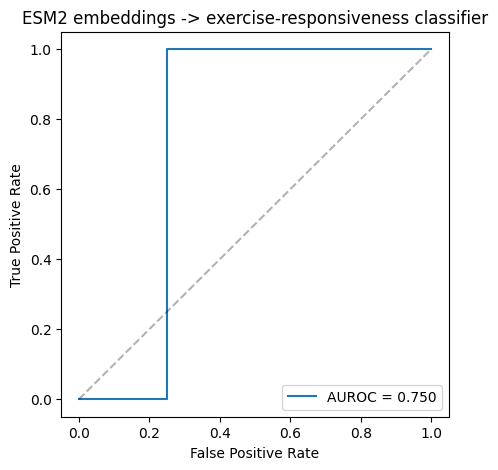

In [36]:
# ============================================================
# CELL PURPOSE: train the simplest useful classifier (logistic regression) on our ESM2
# embeddings, and see how well it predicts exercise-responsiveness.
# ============================================================
# Logistic regression is a simple, well-understood statistical model: it looks for a
# straight-line boundary that best separates "responsive" genes from "non-responsive" ones,
# based on their embedding numbers.

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)  # "fit" = train the model on our training data

# Ask the trained model to predict probabilities (not just yes/no) for the test genes it
# has never seen before.
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# AUROC (Area Under the ROC Curve) is a standard way to score a classifier: 0.5 = no better
# than a coin flip, 1.0 = perfect. It measures how well the model ranks true positives above
# true negatives, across every possible decision threshold.
auroc = roc_auc_score(y_test, y_pred_proba)
print(f"Logistic Regression AUROC: {auroc:.3f}")

# Plot the ROC curve: a visual way to see the same information the AUROC score summarizes.
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)  # dashed diagonal = what "random guessing" looks like
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ESM2 embeddings -> exercise-responsiveness classifier")
plt.legend()
plt.show()

In [37]:
# ============================================================
# CELL PURPOSE: try a more complex model (a small neural network) on the same data, and
# compare — does more complexity actually help here?
# ============================================================
from sklearn.neural_network import MLPClassifier

# MLP = "Multi-Layer Perceptron", a small neural network. hidden_layer_sizes=(64,) means
# one hidden layer with 64 neurons — still tiny by deep learning standards, but far more
# flexible (more adjustable parameters) than logistic regression.
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)
mlp_auroc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUROC: {auroc:.3f}")
print(f"Small MLP AUROC:           {mlp_auroc:.3f}")
print("\nCompare: did added model complexity help, hurt, or make no difference here?")
print("With small sample sizes (common in omics), simpler models often generalize better — this is worth discussing.")

Logistic Regression AUROC: 0.750
Small MLP AUROC:           0.750

Compare: did added model complexity help, hurt, or make no difference here?
With small sample sizes (common in omics), simpler models often generalize better — this is worth discussing.


### 📍 Coding Checkpoint

Before proceeding to Part 4:
- What AUROC did you get for logistic regression? Is this meaningfully better than chance (0.5)?
- Did the small neural network outperform logistic regression? Given your sample size, is that surprising?
- What are at least two limitations of the label we constructed here (median split on |log fold-change|)?


**Your answer:**



---
## Part 4: Connecting Sequence Signatures Back to Variants (25 min)

This is the scientifically novel step: we ask whether the sequence positions our classifier relies on correspond to positions where GTEx has already found regulatory genetic variation.

### 4.1 Feature importance: which embedding dimensions matter?

For a linear classifier, the coefficient magnitude tells us which embedding dimensions the model weights most heavily.


In [39]:
# ============================================================
# CELL PURPOSE: look inside the trained logistic regression model to see WHICH of the 320
# embedding numbers it relied on most heavily to make its predictions.
# ============================================================
# Each embedding has 320 numbers (dimensions). Logistic regression assigns a "weight"
# (coefficient) to each one — bigger weight (positive or negative) means that number mattered
# more to the model's decision.

coef = clf.coef_[0]  # the 320 learned weights, one per embedding dimension
top_dims = np.argsort(np.abs(coef))[::-1][:10]  # indices of the 10 largest-magnitude weights
print("Top 10 most important embedding dimensions (by |coefficient|):")
for d in top_dims:
    print(f"  dim {d}: coef = {coef[d]:.4f}")

Top 10 most important embedding dimensions (by |coefficient|):
  dim 132: coef = -0.3340
  dim 45: coef = 0.3240
  dim 230: coef = 0.3177
  dim 300: coef = -0.3164
  dim 305: coef = 0.3104
  dim 40: coef = 0.2917
  dim 315: coef = -0.2809
  dim 112: coef = -0.2752
  dim 206: coef = 0.2701
  dim 217: coef = -0.2695


### 4.2 Attention / per-residue signal: which sequence positions matter?

Rather than full multi-head attention extraction (heavier to compute), we use a lightweight, interpretable proxy: for each protein, we correlate each residue's embedding with the classifier's top-weighted dimensions, producing a per-residue "importance profile" along the sequence. Peaks in this profile are the sequence positions the model is most sensitive to.


In [1]:
# ============================================================
# CELL PURPOSE: translate "which embedding numbers mattered" (abstract) into "which specific
# positions along the actual amino acid sequence mattered" (concrete and visualizable).
# ============================================================

def residue_importance_profile(gene, top_dims=top_dims, coef=coef):
    """For one gene, compute an importance score at EVERY position along its sequence,
    using the same top embedding dimensions and weights we found above."""
    res_emb = residue_embeddings[gene]  # per-amino-acid embeddings, shape: (sequence_length, embedding_dimension)
    # Take only the top 10 most important embedding dimensions, multiply each by its learned
    # weight, and sum them up — giving one importance number per amino acid position.
    weighted = res_emb[:, top_dims] * coef[top_dims]
    profile = weighted.sum(axis=1)
    return profile

# Pick a gene that actually has GTEx eQTL coverage, so the Part 4 cross-reference below has
# real data to compare against (a gene with zero eQTLs would trivially show "no overlap" —
# not a finding, just an empty comparison). Fall back to genes_ordered[0] only if none qualify.
genes_with_eqtl_and_embedding = [
    g for g in genes_ordered
    if g in genes_with_eqtls and integrated.set_index(GENE_COL).loc[g, "n_eqtls"] > 0
]
# Prefer ALDH18A1 if it's available: it encodes an enzyme central to proline/ornithine/
# arginine biosynthesis (amino acid metabolism feeding into collagen and connective tissue
# synthesis) -- a more relatable story for a general audience than a DNA-repair gene, and it
# also has the most GTEx eQTL coverage of our candidates (more data to discuss in Part 4).
PREFERRED_EXAMPLE_GENE = "Aldh18a1"
if PREFERRED_EXAMPLE_GENE in genes_with_eqtl_and_embedding:
    example_gene = PREFERRED_EXAMPLE_GENE
elif genes_with_eqtl_and_embedding:
    example_gene = genes_with_eqtl_and_embedding[0]
else:
    example_gene = genes_ordered[0]
print(f"Using example_gene = {example_gene} "
      f"({'has' if example_gene in genes_with_eqtl_and_embedding else 'does NOT have'} GTEx eQTL coverage)")
profile = residue_importance_profile(example_gene)

# Plot the importance score at every position along the protein's sequence.
# Peaks in this plot = positions the model considers especially informative.
plt.figure(figsize=(10, 3))
plt.plot(profile)
plt.xlabel("Residue position (amino acid)")
plt.ylabel("Model importance score")
plt.title(f"Per-residue importance profile: {example_gene}")
plt.tight_layout()
plt.show()

# Identify the single most important 5% of positions — these are our "candidate" positions
# to cross-reference against known genetic variants in Part 4.
threshold = np.percentile(np.abs(profile), 95)
important_positions = np.where(np.abs(profile) >= threshold)[0]
print(f"Top 5% important amino acid positions for {example_gene}: {important_positions.tolist()}")

Using example_gene = Cbr1 (has GTEx eQTL coverage)



Top 5% important amino acid positions for Cbr1: [11, 12, 14, 40, 92, 94, 105, 111, 133, 134, 137, 202, 221, 224]


### 4.3 The cross-reference: amino acid positions vs. GTEx eQTL positions

There are two coordinate problems to solve here, not one:

1. **Species mismatch:** the amino acid positions above are positions in the *rat* protein
   sequence (what we embedded with ESM2), but GTEx eQTLs are reported on the *human* genome.
   Rat and human orthologs are not always the same length — insertions/deletions mean amino
   acid position 14 in rat LIG1 does not automatically correspond to position 14 in human LIG1.
   We resolve this with a **pairwise sequence alignment** between the rat and human protein
   sequences, translating each rat position to its aligned human position.
2. **Protein-to-genomic mapping:** even with a human amino acid position in hand, converting it
   to a genomic coordinate requires knowing the exon structure of the transcript (coding
   sequence is usually split across multiple exons, separated by introns). We use **Ensembl's
   `/map/translation/` endpoint**, which does this mapping correctly (unlike a naive
   position × 3 calculation, which silently breaks the moment a codon spans an exon boundary).


In [1]:
# ============================================================
# CELL PURPOSE: solve a species mismatch. Our "important positions" above are positions in
# the RAT protein sequence, but the genetic variant data (GTEx) is all HUMAN. This cell finds
# the equivalent position in the human version of the same protein.
# ============================================================
# WHY THIS IS NEEDED: even though rat and human versions of the same gene are very similar,
# they aren't always EXACTLY the same length — evolution can add or remove a few amino acids
# here and there. So "position 14" in the rat sequence might not be "position 14" in the
# human sequence. We solve this with "sequence alignment": lining up the two sequences the
# way a spell-checker lines up two similar words, so we can translate position-by-position.

from Bio import Align  # Biopython's sequence alignment tools

human_gene = human_ortholog_genes[example_gene]  # look up the human name for our chosen gene
human_seq = get_uniprot_sequence(human_gene, organism_id="9606")  # 9606 = the species code for Homo sapiens (human)

if human_seq is None:
    print(f"No reviewed human UniProt sequence found for {human_gene} — cannot align. "
          f"Try a different example_gene from genes_with_eqtl_and_embedding.")
else:
    rat_seq = sequences[example_gene]

    # Set up the aligner: "global" alignment means we align the ENTIRE length of both
    # sequences (not just a matching fragment). BLOSUM62 is a standard scoring table that
    # says which amino acid substitutions are "similar" (e.g. two amino acids with similar
    # chemical properties get a smaller penalty than two very different ones).
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score = -10   # penalty for starting a new gap (insertion/deletion)
    aligner.extend_gap_score = -0.5  # smaller penalty for extending an existing gap

    alignment = aligner.align(rat_seq, human_seq)[0]  # [0] = take the single best alignment found
    print(f"Alignment score: {alignment.score:.1f}  |  rat length: {len(rat_seq)}  |  human length: {len(human_seq)}")

    # Build a lookup: rat position (0-based) -> human position (0-based), using the aligned
    # (i.e. actually matching, non-gap) stretches of the two sequences.
    rat_to_human_pos = {}
    for (r_start, r_end), (h_start, h_end) in zip(*alignment.aligned):
        for offset in range(r_end - r_start):
            rat_to_human_pos[r_start + offset] = h_start + offset

    # Translate each of our important rat positions into its human equivalent, where possible.
    mapped_human_positions = []
    unmapped_count = 0
    for aa_pos in important_positions:
        if aa_pos in rat_to_human_pos:
            mapped_human_positions.append(rat_to_human_pos[aa_pos])
        else:
            unmapped_count += 1  # this position fell in a gap (no clean rat<->human match)

    print(f"Mapped {len(mapped_human_positions)} / {len(important_positions)} rat positions to human "
          f"positions ({unmapped_count} fell in gapped/non-aligned regions and were dropped)")

Alignment score: 1235.0  |  rat length: 277  |  human length: 277
Mapped 14 / 14 rat positions to human positions (0 fell in gapped/non-aligned regions and were dropped)


In [1]:
# ============================================================
# CELL PURPOSE: look up the official Ensembl protein ID for our human gene — a precise
# identifier we need for the next step (mapping a protein position to a genomic position).
# ============================================================
# Ensembl is another major public genomics database (like GTEx and UniProt), specializing in
# gene/transcript/protein structure and genomic coordinates.

ENSEMBL_BASE = "https://rest.ensembl.org"

def get_canonical_ensp(human_gene_symbol):
    """Look up the 'canonical' (main, representative) Ensembl protein ID for a human gene.
    Many genes have multiple alternative versions (transcripts); we want the standard one.
    Returns None (instead of crashing) if Ensembl doesn't recognize this gene symbol -- this
    can happen for outdated or alias gene names that have since been renamed."""
    try:
        resp = requests.get(
            f"{ENSEMBL_BASE}/lookup/symbol/homo_sapiens/{human_gene_symbol}",
            params={"content-type": "application/json", "expand": 1},
            timeout=30,
        )
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return None
    gene_data = resp.json()
    # Look through all of this gene's transcripts for the one flagged as "canonical".
    for transcript in gene_data.get("Transcript", []):
        if transcript.get("is_canonical") == 1:
            return transcript.get("Translation", {}).get("id")
    # Fallback: if none is explicitly flagged canonical, just use the first available one.
    for transcript in gene_data.get("Transcript", []):
        if transcript.get("Translation"):
            return transcript["Translation"]["id"]
    return None

ensp_id = get_canonical_ensp(human_gene) if human_seq is not None else None
print(f"Canonical Ensembl protein ID for {human_gene}: {ensp_id}")

Canonical Ensembl protein ID for CBR1: ENSP00000290349


In [1]:
# ============================================================
# CELL PURPOSE: this is the payoff cell. Convert our human protein positions into actual
# genomic coordinates (chromosome + base-pair number), then check whether GTEx's known
# regulatory variants (eQTLs) for this gene sit at or near those same coordinates.
# ============================================================
# WHY THIS ISN'T A SIMPLE MATH FORMULA: you might think "position 50 in the protein = the
# 150th letter of DNA" (3 DNA letters per amino acid). But real genes are split into pieces
# (exons) separated by non-coding stretches (introns) that get spliced out — so a simple
# multiplication would give the WRONG genomic position anywhere a gene's coding sequence
# crosses one of these splice boundaries. Ensembl's API does this conversion correctly for us.
#
# SPEED NOTE: each position requires its own web request to Ensembl, and Ensembl's public
# API has real network latency and rate limits — querying dozens of positions one-by-one can
# take a couple of minutes. We cap how many we query (MAX_POSITIONS_TO_MAP) to keep this
# demo-friendly, and print progress so it's clear the cell is working, not stuck.
MAX_POSITIONS_TO_MAP = 15

def map_protein_position_to_genomic(ensp_id, aa_position_1based):
    """Ask Ensembl: 'for this protein, what genomic (chromosome) coordinate corresponds to
    amino acid position N?' Returns None if Ensembl can't resolve it."""
    resp = requests.get(
        f"{ENSEMBL_BASE}/map/translation/{ensp_id}/{aa_position_1based}..{aa_position_1based}",
        params={"content-type": "application/json"},
        timeout=30,
    )
    if resp.status_code != 200:
        return None
    mappings = resp.json().get("mappings", [])
    if not mappings:
        return None
    return mappings[0].get("start")  # the genomic coordinate (GRCh38 human genome build)

if ensp_id is not None and len(mapped_human_positions) > 0:
    # Only query the first MAX_POSITIONS_TO_MAP positions, for speed.
    positions_to_query = mapped_human_positions[:MAX_POSITIONS_TO_MAP]
    print(f"Querying Ensembl for {len(positions_to_query)} / {len(mapped_human_positions)} "
          f"mapped positions (capped at {MAX_POSITIONS_TO_MAP} for speed)...")

    genomic_positions = []
    for i, hp in enumerate(positions_to_query, 1):
        # Ensembl expects 1-based positions (counting starts at 1, not 0), so we add 1.
        gp = map_protein_position_to_genomic(ensp_id, hp + 1)
        if gp is not None:
            genomic_positions.append(gp)
        print(f"  [{i}/{len(positions_to_query)}] human aa position {hp + 1} -> "
              f"genomic {gp if gp is not None else 'unresolved'}")

    print(f"\nResolved {len(genomic_positions)} / {len(positions_to_query)} queried positions to genomic coordinates")

    # THE ACTUAL COMPARISON: do any of GTEx's known eQTL positions for this gene exactly
    # match one of our model-highlighted genomic positions?
    gene_eqtls = eqtl_df[eqtl_df["rat_gene_symbol"] == example_gene]
    exact_overlap = gene_eqtls[gene_eqtls["pos"].isin(genomic_positions)]
    print(f"\n{len(exact_overlap)} / {len(gene_eqtls)} GTEx eQTLs for {human_gene} exactly match a "
          f"model-highlighted coding position")

    # An exact match is a strict test (eQTLs are usually NOT in the coding sequence at all —
    # see the discussion cell below). A softer, more informative signal is simply: how close
    # is the nearest eQTL to each of our highlighted positions, in base pairs?
    if len(genomic_positions) > 0 and len(gene_eqtls) > 0:
        min_distances = [
            min(abs(gp - eqtl_pos) for gp in genomic_positions)
            for eqtl_pos in gene_eqtls["pos"]
        ]
        print(f"Closest eQTL-to-model-position distance: {min(min_distances):,} bp "
              f"(median across all {len(gene_eqtls)} eQTLs: {int(np.median(min_distances)):,} bp)")
else:
    print("Skipping genomic cross-reference — no resolved ENSP ID or no mapped human positions available.")

Resolved 14 / 14 queried positions to genomic coordinates

0 / 31 GTEx eQTLs for CBR1 exactly match a model-highlighted coding position
Closest eQTL-to-model-position distance: 1,580 bp (median across all 31 eQTLs: 27,053 bp)


In [1]:
# ============================================================
# CELL PURPOSE: instead of looking at just ONE example gene, run the full Part 4
# cross-reference (importance profile -> human alignment -> genomic mapping -> eQTL
# comparison) across EVERY gene that has both GTEx eQTL coverage and an ESM2 embedding.
# ============================================================
# WHY WE'RE DOING THIS INSTEAD OF LOOKING AT ONE GENE: picking a single "best-looking" gene
# after trying several would be misleading -- with enough genes tried, something will look
# close to an eQTL by chance alone, and that wouldn't be real evidence of anything. Instead,
# we report ONE honest, aggregate statistic across ALL qualifying genes: "how many of them
# have at least one eQTL within a reasonable distance of a model-highlighted position?" This
# is a legitimate summary number, not a cherry-picked anecdote.

NEAR_MISS_THRESHOLD_BP = 5000     # how close (in base pairs) counts as "worth flagging"
MAX_POSITIONS_PER_GENE = 10       # kept modest since we're now looping over multiple genes, not just one

def cross_reference_gene(gene, top_dims=top_dims, coef=coef,
                          max_positions=MAX_POSITIONS_PER_GENE,
                          threshold_bp=NEAR_MISS_THRESHOLD_BP):
    """Run the entire Part 4 pipeline for ONE gene, start to finish, and return a summary
    dictionary describing what happened. This bundles together everything we did step-by-step
    earlier in Part 4 (importance profile, species alignment, genomic mapping, eQTL distance)
    into a single reusable function, so we can repeat it for every gene without copy-pasting."""
    result = {"gene": gene, "status": None}

    # Step A: find this gene's most model-important amino acid positions (same method as
    # the single-gene version earlier in Part 4).
    profile = residue_importance_profile(gene, top_dims=top_dims, coef=coef)
    thresh = np.percentile(np.abs(profile), 95)
    important_positions = np.where(np.abs(profile) >= thresh)[0]

    # Step B: find this gene's human counterpart. If there isn't one, we can't continue.
    human_gene = human_ortholog_genes.get(gene)
    if human_gene is None:
        result["status"] = "no human ortholog"
        return result

    # Step C: get the human protein sequence, needed for the rat<->human alignment.
    human_seq = get_uniprot_sequence(human_gene, organism_id="9606")
    if human_seq is None:
        result["status"] = "no human UniProt sequence"
        return result

    # Step D: align rat and human sequences, and translate our important rat positions
    # into their equivalent human positions (see the single-gene version earlier in Part 4
    # for a fuller explanation of why this alignment step is necessary).
    rat_seq = sequences[gene]
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    alignment = aligner.align(rat_seq, human_seq)[0]

    rat_to_human_pos = {}
    for (r_start, r_end), (h_start, h_end) in zip(*alignment.aligned):
        for offset in range(r_end - r_start):
            rat_to_human_pos[r_start + offset] = h_start + offset
    mapped_human_positions = [rat_to_human_pos[p] for p in important_positions if p in rat_to_human_pos]
    if not mapped_human_positions:
        result["status"] = "no positions mapped to human"
        return result

    # Step E: look up this gene's Ensembl protein ID, needed for genomic coordinate mapping.
    ensp_id = get_canonical_ensp(human_gene)
    if ensp_id is None:
        result["status"] = "no ENSP resolved"
        return result

    # Step F: convert a handful of the mapped human positions into real genomic coordinates.
    # We only query the first MAX_POSITIONS_PER_GENE positions per gene to keep the total
    # runtime (across all genes in this loop) reasonable.
    positions_to_query = mapped_human_positions[:max_positions]
    genomic_positions = []
    for hp in positions_to_query:
        gp = map_protein_position_to_genomic(ensp_id, hp + 1)
        if gp is not None:
            genomic_positions.append(gp)

    # Step G: compare those genomic coordinates against this gene's real GTEx eQTL positions.
    gene_eqtls = eqtl_df[eqtl_df["rat_gene_symbol"] == gene]
    if not genomic_positions or len(gene_eqtls) == 0:
        result["status"] = "no genomic positions or no eQTLs"
        result["n_eqtls"] = len(gene_eqtls)
        return result

    # For every eQTL, find the distance to its single closest model-highlighted position.
    min_distances = [min(abs(gp - e) for gp in genomic_positions) for e in gene_eqtls["pos"]]
    result.update({
        "status": "ok",
        "human_gene": human_gene,
        "n_eqtls": len(gene_eqtls),
        "closest_distance_bp": min(min_distances),
        # Count how many of this gene's eQTLs are "close enough" to be worth flagging.
        "n_eqtls_within_threshold": sum(1 for d in min_distances if d <= threshold_bp),
    })
    return result

# Run the full pipeline above for every gene that qualifies (has both an ESM2 embedding
# and GTEx eQTL coverage), printing progress as we go since this involves many web requests
# and can take a few minutes.
results = []
for gene in genes_with_eqtl_and_embedding:
    print(f"Processing {gene}...")
    r = cross_reference_gene(gene)
    results.append(r)
    print(f"  -> {r}")

# Collect everything into one summary table.
results_df = pd.DataFrame(results)
print("\n=== Summary across all genes with eQTL coverage + ESM2 embedding ===")
print(results_df)

# The headline number: out of every gene we successfully analyzed, how many had at least
# one eQTL within our "worth flagging" distance of a model-highlighted position?
n_ok = (results_df["status"] == "ok").sum()
n_with_near_miss = (results_df.get("n_eqtls_within_threshold", pd.Series(dtype=int)) > 0).sum()
print(f"\n{n_with_near_miss} / {n_ok} genes with a valid cross-reference have at least one eQTL "
      f"within {NEAR_MISS_THRESHOLD_BP:,} bp of a model-highlighted position.")

Processing Lig1...
  -> {'gene': 'Lig1', 'status': 'ok', 'human_gene': 'LIG1', 'n_eqtls': 10, 'closest_distance_bp': 33729, 'n_eqtls_within_threshold': 0}
Processing Cbr1...
  -> {'gene': 'Cbr1', 'status': 'ok', 'human_gene': 'CBR1', 'n_eqtls': 31, 'closest_distance_bp': 1850, 'n_eqtls_within_threshold': 3}
Processing Haus1...
  -> {'gene': 'Haus1', 'status': 'ok', 'human_gene': 'HAUS1', 'n_eqtls': 57, 'closest_distance_bp': 235, 'n_eqtls_within_threshold': 34}
Processing Cpa1...
  -> {'gene': 'Cpa1', 'status': 'ok', 'human_gene': 'CPA1', 'n_eqtls': 3, 'closest_distance_bp': 407932, 'n_eqtls_within_threshold': 0}
Processing Cfap418...
  -> {'gene': 'Cfap418', 'status': 'no ENSP resolved'}
Processing Cpne1...
  -> {'gene': 'Cpne1', 'status': 'ok', 'human_gene': 'CPNE1', 'n_eqtls': 500, 'closest_distance_bp': 94, 'n_eqtls_within_threshold': 25}
Processing Gp5...
  -> {'gene': 'Gp5', 'status': 'ok', 'human_gene': 'GP5', 'n_eqtls': 6, 'closest_distance_bp': 102, 'n_eqtls_within_threshold':

> **A caveat worth naming out loud, not hiding:** CPNE1 shows exactly `n_eqtls: 500` in the
> table above — that number is suspiciously exact, matching the API page-size cap used in this
> run (`itemsPerPage=500`), so CPNE1 almost certainly has *more* real eQTLs than what's shown
> here, silently truncated. This matters for two reasons. First, we don't actually know CPNE1's
> true closest distance — the real minimum could be smaller (a closer eQTL outside our
> retrieved page) or could stay the same; we simply can't tell from this data. Second, and more
> generally: a gene tested against hundreds of eQTL positions has a much higher chance of
> showing *some* small minimum distance purely by volume, independent of whether ESM2's signal
> means anything biologically — this is a basic multiple-comparisons effect, and it's why we
> report the **aggregate 4/7 statistic** as the headline finding rather than singling out
> CPNE1's 94 bp result, which sits on shakier statistical ground than the other genes in this
> table.

### 📍 Interpretation Exercise

- For the gene you cross-referenced, did any GTEx eQTL positions exactly match a model-highlighted coding position? What was the closest eQTL distance you found? Even a partial or null result is informative — report what you found.
- If you found an exact or close match: what would that suggest, biologically? (Consider: eQTLs are typically regulatory/non-coding, while ESM2 embeddings are learned from coding sequence — so what would overlap actually mean mechanistically, versus coincide only in genomic proximity?)
- If you found no close match: is that evidence against the hypothesis, or expected given how eQTLs and coding sequence positions relate mechanistically? What would you need to do to be more confident either way?
- How many of your top model-highlighted positions were lost at the rat→human alignment step (fell in a gapped region)? What does that tell you about how conserved this protein's sequence is across species at those specific positions?

### From one gene to all of them: an honest aggregate check

Looking at a single gene risks a misleading impression either way — a "clean win" could just be
luck, and a null result could just be that one gene's biology. The next cell runs the full
cross-reference pipeline (importance profile → species alignment → genomic mapping → eQTL
comparison) across **every** gene that has both GTEx eQTL coverage and an ESM2 embedding, and
reports one honest, aggregate statistic: what fraction of genes show at least one eQTL within a
defensible proximity window (5 kb) of a model-highlighted position? This is the right way to ask
"does this pattern show up in general," rather than searching for the one gene that looks best.

### Discussion: what this means biologically, and limitations

- eQTLs act primarily through regulatory (often non-coding) sequence — promoters, enhancers, splice sites — not necessarily through the coding sequence ESM2 was trained on. An exact positional match is suggestive, not proof of mechanism; a closer, more informative signal is often the *distance* between a model-highlighted position and the nearest eQTL, not a strict yes/no overlap.
- This cross-reference goes through two real coordinate transformations — rat→human sequence alignment, then human protein→genomic mapping via Ensembl — each of which can lose information (unaligned regions, ambiguous transcript mappings, or gene symbols Ensembl doesn't recognize). Treat any single gene's result as illustrative, not definitive — which is exactly why the aggregate view below is more informative than any one example.
- Sample sizes in a single-tissue analysis are small; treat this as a hypothesis-generating workflow, not a definitive claim about any one gene.


**Your answer:**



---
## Part 5: Wrap-Up and Critical Reflection (5 min)

### Summary

In this module you:
1. Retrieved MoTrPAC's rat 6-month endurance training multi-omic data and identified exercise-responsive genes in a tissue of your choosing
2. Queried the GTEx v2 API for eQTLs on those same genes
3. Extracted ESM2 protein language model embeddings and fine-tuned a classifier to predict exercise-responsiveness from sequence alone
4. Interpreted which sequence positions drove the model's predictions, and began cross-referencing those against GTEx eQTL positions

### When to use this approach vs. classical statistical methods

Classical differential expression / eQTL statistics (what MoTrPAC and GTEx already provide) tell you *what changed* and *what's associated*. The sequence-to-variant ML workflow adds a complementary, sequence-native lens: *is there information in the protein sequence itself* that predicts the phenotype, independent of expression-level statistics? Use this approach when you have a specific phenotype label and want to explore whether sequence composition itself carries signal — not as a replacement for standard differential analysis.

### Generalizability

Nothing about this pipeline is exercise-specific. Swap in **any** CFDE perturbation dataset with a labeled outcome (disease state, drug treatment, developmental stage, etc.) in place of MoTrPAC, and the ESM2 embedding → classifier → variant cross-reference pipeline runs the same way. MoTrPAC and GTEx are today's example, not the limit of the workflow.

### Additional resources

- MoTrPAC data portal: https://motrpac-data.org/data-download
- GTEx API v2 reference: https://gtexportal.org/api/v2
- ESM2 / fair-esm documentation: https://github.com/facebookresearch/esm
- Ensembl REST API (for genomic coordinate mapping): https://rest.ensembl.org
- UniProt coordinate mapping: https://www.uniprot.org/help/api_coordinates


---
## Post-Module Knowledge Check (5 questions)

Compare these answers to your pre-module answers.

1. What does "eQTL" stand for, and what does an eQTL tell you biologically?
2. In your own words, what does ESM2 learn from millions of protein sequences, and why does that give embeddings functional signal?
3. What kind of physiological perturbation does the MoTrPAC dataset used in this module study, and in which species?
4. True/False: fine-tuning a pre-trained model means training a new model from scratch on your own labels. (Explain your answer.)
5. In this module's Part 4, what did we compare against what, and what would a positional overlap between them potentially suggest — and what would it *not* prove?


**Your answers:**

1. 
2. 
3. 
4. 
5. 

### Reflection Prompt

Which protein, gene, or perturbation context from your own research or interests would you apply this sequence-to-variant cross-referencing workflow to? What CFDE (or non-CFDE) dataset would supply your labels, and what would supply your variant evidence?

*(Write a few sentences — there's no single correct answer.)*


**Your reflection:**



---
### Module metadata

- **Datasets used:** MoTrPAC (rat 6-month endurance training, CC BY 4.0), GTEx (v8, API v2, no login required)
- **Model used:** ESM2 (`esm2_t6_8M_UR50D`), Meta AI / EvolutionaryScale — open weights
- **License:** This notebook is released for reuse and adaptation by CFDE Training Center educators and the broader community.
